### Imports

In [19]:
import os
import pandas as pd
import mlflow
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import mlflow.sklearn
import xgboost as xgb
from dotenv import load_dotenv

load_dotenv("../.env")

True

### Set up DB and MLFlow Connections

In [20]:

PG_HOST = os.getenv("PG_HOST")
PG_PORT = os.getenv("PG_PORT")
PG_USER = os.getenv("PG_USER")
PG_PASS = os.getenv("PG_PASS")
PG_DB = "mushrooms_dev"
RAW_SCHEMA = os.getenv("USER") + "_raw"
INTERMEDIATE_SCHEMA = os.getenv("USER") + "_intermediate"
CONSUMPTION_SCHEMA = os.getenv("USER") + "_consumption"

# Set remote MLflow
mlflow.set_tracking_uri(f"http://{PG_HOST}:5000")

# Postgres connection 
db_url = f"postgresql+psycopg2://{PG_USER}:{PG_PASS}@{PG_HOST}:{PG_PORT}/{PG_DB}"
engine = create_engine(db_url)

### Get Data

In [21]:

TABLE = f"{INTERMEDIATE_SCHEMA}.mushrooms_encoded_for_xgb_pre"

df = pd.read_sql(f"SELECT * FROM {TABLE};", engine)

print(df.shape)
print(df.head())

(2717, 24)
   mushroom_id  label_encoded  f01_encoded  f02_encoded  f03_encoded  \
0            1              1            2            0            3   
1            2              0            2            3            2   
2            3              0            5            0            4   
3            4              0            2            3            2   
4            5              0            3            3            2   

   f04_encoded  f05_encoded  f06_encoded  f07_encoded  f08_encoded  ...  \
0            0            2            1            0            0  ...   
1            1            5            1            0            0  ...   
2            1            5            1            0            0  ...   
3            1            5            1            0            0  ...   
4            1            5            1            0            0  ...   

   f13_encoded  f14_encoded  f15_encoded  f16_encoded  f17_encoded  \
0            1            6        

In [22]:
features = [col for col in df.columns if col.startswith('f')]  # f01_encoded ... f22_encoded
X = df[features]
y = df['label_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=27, stratify=y)

### Tracer Util

In [23]:
import os
import time
from pathlib import Path

def get_notebook_info():
    # Unix epoch
    epoch = int(time.time())
    
    # Username
    user = os.getenv("USER", os.getenv("USERNAME", "unknown"))
    
    # fallback name
    notebook_name = "unknown_notebook.ipynb"
    
    if "__vsc_ipynb_file__" in globals():
        notebook_name = Path(__vsc_ipynb_file__).name  # VS Code
    elif os.getenv("JPY_SESSION_NAME"):
        notebook_name = Path(os.getenv("JPY_SESSION_NAME")).name  # JupyterLab/Server 2.0+
    elif "google.colab" in str(get_ipython()):  # Google Colab
        notebook_name = "colab_notebook.ipynb"  # Colab doesn't expose reliably
    elif "kaggle" in os.getenv("HOSTNAME", ""):  # Kaggle (approx)
        notebook_name = "kaggle_notebook.ipynb"
    else:
        try:
            import ipynbname  # pip install ipynbname (classic Jupyter)
            notebook_name = ipynbname.name()
        except:
            pass
    
    return f"{epoch}~{user}~{notebook_name}"

trace_id = get_notebook_info()
print(trace_id)  # e.g. "1710148800~busboy~mushroom_train.ipynb"


1773027440~graxel~train_xgboost.ipynb


### Train and Log Model

In [24]:
from mlflow.models import infer_signature
from mlflow.types.schema import ParamSchema, ParamSpec


mlflow.set_experiment("mushroom-xgb-vary-n_estimators")

with mlflow.start_run():
    n_estimators = 3
    mlflow.log_param("n_estimators", n_estimators)
    model = xgb.XGBClassifier(n_estimators=n_estimators, random_state=26, eval_metric='logloss', )
    model.fit(X_train, y_train)
    
    signature = infer_signature(X_train, model.predict(X_train))
    mlflow.xgboost.log_model(model, signature=signature, name="xgb-mushroom-model", registered_model_name="mushroom-classifier-low-estimators")

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    # Log accuracies
    mlflow.log_metric("test_accuracy", acc)
    mlflow.log_metric("train_accuracy", model.score(X_train, y_train))
    print(f"Logged model with accuracy: {acc:.4f}")
    
    # Log feature importances
    importances = dict(zip(features, model.feature_importances_))
    for feat, imp in importances.items():
        mlflow.log_metric(f"feature_importance_{feat}", imp)
    
    # Log traceability artifact
    mlflow.log_param("trace_id", trace_id)

    print(classification_report(y_test, y_pred))


/Users/graxel/repos/mushrooms/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/03/08 23:37:25 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
Registered model 'mushroom-classifier-low-esti

Logged model with accuracy: 0.9926
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       278
           1       1.00      0.98      0.99       266

    accuracy                           0.99       544
   macro avg       0.99      0.99      0.99       544
weighted avg       0.99      0.99      0.99       544

🏃 View run youthful-goose-298 at: http://192.168.0.100:5000/#/experiments/8/runs/39880728e5a9403f9d87a5967078aa25
🧪 View experiment at: http://192.168.0.100:5000/#/experiments/8


### Retrieve experiment

In [25]:
import mlflow
from mlflow.tracking import MlflowClient

mlflow.set_tracking_uri("http://192.168.0.100:5000")
client = MlflowClient()

# Get the experiment by name
experiment = client.get_experiment_by_name("mushroom-xgb-vary-n_estimators")

# Search runs, ordered by start time descending
runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["start_time DESC"]
)

# Latest run
latest_run = runs[0]
print(latest_run.info.run_id)
for k,v in latest_run.data.metrics.items():
    print(k,v)

# Load it
model = mlflow.xgboost.load_model("models:/mushroom-classifier-low-estimators/latest")
pfmodel = mlflow.pyfunc.load_model("models:/mushroom-classifier-low-estimators/latest")

39880728e5a9403f9d87a5967078aa25
test_accuracy 0.9926470588235294
train_accuracy 0.9944776806258628
feature_importance_f01_encoded 0.0
feature_importance_f02_encoded 0.01403695996850729
feature_importance_f03_encoded 0.004130393732339144
feature_importance_f04_encoded 0.036832891404628754
feature_importance_f05_encoded 0.03133508935570717
feature_importance_f06_encoded 0.0
feature_importance_f07_encoded 0.0
feature_importance_f08_encoded 0.11012057214975357
feature_importance_f09_encoded 0.36720675230026245
feature_importance_f10_encoded 0.025874150916934013
feature_importance_f11_encoded 0.01507785264402628
feature_importance_f12_encoded 0.0
feature_importance_f13_encoded 0.008898659609258175
feature_importance_f14_encoded 0.023449933156371117
feature_importance_f15_encoded 0.007424808572977781
feature_importance_f16_encoded 0.0
feature_importance_f17_encoded 0.0
feature_importance_f18_encoded 0.0011027967557311058
feature_importance_f19_encoded 0.0
feature_importance_f20_encoded 0.17


=== Train ===
Accuracy: 0.9945
Precision: 1.0000
Recall:    0.9887
F1-score:  0.9943
F32-score (F√1000): 0.9887
Prediction time: 0.001824 s total, 0.0008 ms/row
Confusion matrix:
[[1111    0]
 [  12 1050]]

Classification report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1111
           1       1.00      0.99      0.99      1062

    accuracy                           0.99      2173
   macro avg       0.99      0.99      0.99      2173
weighted avg       0.99      0.99      0.99      2173


=== Test ===
Accuracy: 0.9926
Precision: 1.0000
Recall:    0.9850
F1-score:  0.9924
F32-score (F√1000): 0.9850
Prediction time: 0.001775 s total, 0.0033 ms/row
Confusion matrix:
[[278   0]
 [  4 262]]

Classification report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       278
           1       1.00      0.98      0.99       266

    accuracy                           0.99       54

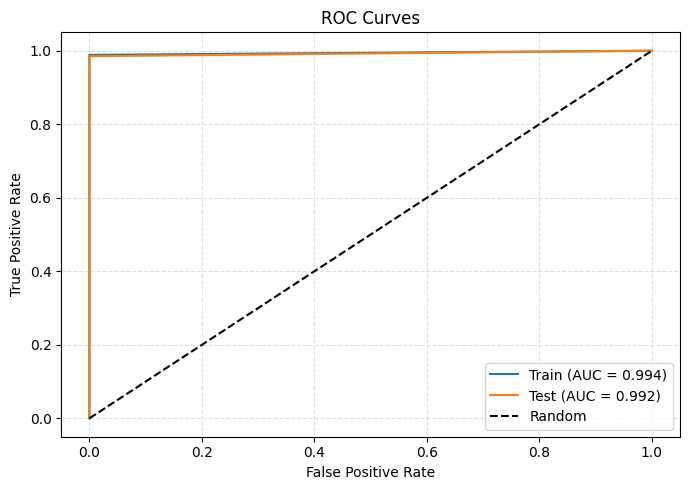

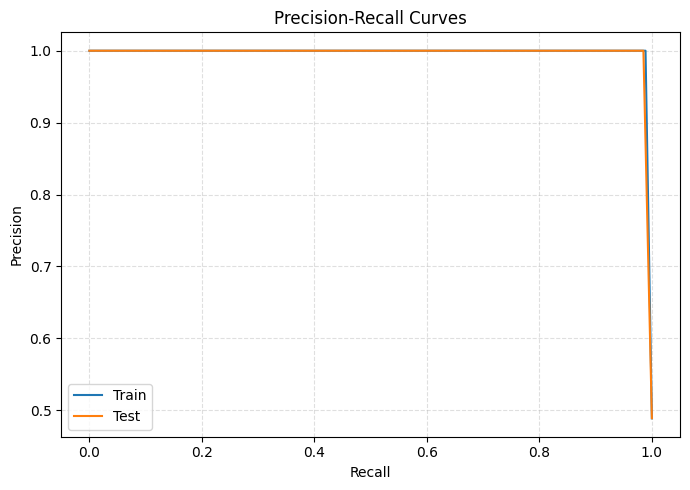


=== Summary (ms per row) ===
Train: 0.0008 ms/row
Test: 0.0033 ms/row

=== Summary (Precision / Recall / F1) ===
Train: Precision=1.0000, Recall=0.9887, F1=0.9943, F32=0.9887
Test: Precision=1.0000, Recall=0.9850, F1=0.9924, F32=0.9850


In [26]:
import numpy as np
import time
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score
)

# Helper to time predictions and compute per-row latency
def timed_predict(model, X, *, n_repeat=5, threshold=0.5):
    """For MLflow PyFuncModel (XGBoost), predict returns probabilities — threshold to get labels."""
    _ = model.predict(X[:10])
    start = time.perf_counter()
    for _ in range(n_repeat):

        y_pred = np.array(model.predict(X))
        if y_pred.ndim == 2:
            y_pred = (y_pred[:, 1] >= threshold).astype(int)
        else:
            y_pred = y_pred.astype(int)


        # raw = model.predict(X)
        # # raw may be a DataFrame or ndarray; extract the positive-class column
        # raw = np.array(raw)
        # if raw.ndim == 2:
        #     y_proba_raw = raw[:, 1]   # shape (n, 2) → take class-1 column
        # else:
        #     y_proba_raw = raw         # shape (n,) → already positive-class proba
        # y_pred = (y_proba_raw >= threshold).astype(int)
    end = time.perf_counter()
    total_time = (end - start) / n_repeat
    ms_per_row = (total_time / len(X)) * 1e3
    return y_pred, total_time, ms_per_row


def timed_predict_proba(model, X, *, n_repeat=5):
    """Extract positive-class probabilities from a PyFuncModel (XGBoost)."""
    _ = model.predict(X[:10])
    start = time.perf_counter()
    for _ in range(n_repeat):
        raw = model.predict(X)
        raw = np.array(raw)
        if raw.ndim == 2:
            y_proba = raw[:, 1]
        else:
            y_proba = raw
    end = time.perf_counter()
    total_time = (end - start) / n_repeat
    ms_per_row = (total_time / len(X)) * 1e3
    return y_proba, total_time, ms_per_row

def evaluate_split(name, model, X, y):
    # Class labels
    y_pred, t_pred, ms_pred = timed_predict(model, X)
    y_proba, t_proba, ms_proba = timed_predict_proba(model, X)

    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, zero_division=0)
    rec = recall_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred, zero_division=0)
    f32 = fbeta_score(y, y_pred, beta=1000**0.5, zero_division=0)


    cm = confusion_matrix(y, y_pred)

    print(f"\n=== {name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"F32-score (F√1000): {f32:.4f}")
    print(f"Prediction time: {t_pred:.6f} s total, {ms_pred:.4f} ms/row")
    print("Confusion matrix:")
    print(cm)
    print("\nClassification report:")
    print(classification_report(y, y_pred, zero_division=0))

    # ROC
    fpr, tpr, _ = roc_curve(y, y_proba)
    roc_auc = auc(fpr, tpr)

    # PR
    prec_curve, rec_curve, _ = precision_recall_curve(y, y_proba)

    return {
        "name": name,
        "y": y,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "fpr": fpr,
        "tpr": tpr,
        "roc_auc": roc_auc,
        "prec_curve": prec_curve,
        "rec_curve": rec_curve,
        "cm": cm,
        "ms_per_row": ms_pred,
        "metrics": {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "f32": f32},
    }

# Evaluate train, test, new
results_train = evaluate_split("Train", pfmodel, X_train, y_train)
results_test = evaluate_split("Test", pfmodel, X_test, y_test)
# results_new = evaluate_split("New", pfmodel, X_new, y_new)

# --- ROC Curves ---
plt.figure(figsize=(7, 5))
for res, color in [
    (results_train, "tab:blue"),
    (results_test, "tab:orange"),
    # (results_new, "tab:green"),
]:
    plt.plot(res["fpr"], res["tpr"], label=f"{res['name']} (AUC = {res['roc_auc']:.3f})", color=color)

plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# --- Precision-Recall Curves ---
plt.figure(figsize=(7, 5))
for res, color in [
    (results_train, "tab:blue"),
    (results_test, "tab:orange"),
    # (results_new, "tab:green"),
]:
    plt.plot(res["rec_curve"], res["prec_curve"], label=res["name"], color=color)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend(loc="lower left")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# --- Summary of ms/row and metrics ---
print("\n=== Summary (ms per row) ===")
for res in [
    results_train,
    results_test, 
    # results_new
    ]:
    print(f"{res['name']}: {res['ms_per_row']:.4f} ms/row")

print("\n=== Summary (Precision / Recall / F1) ===")
for res in [
    results_train,
    results_test, 
    # results_new
    ]:
    m = res["metrics"]
    print(
        f"{res['name']}: "
        f"Precision={m['precision']:.4f}, "
        f"Recall={m['recall']:.4f}, "
        f"F1={m['f1']:.4f}, "
        f"F32={m['f32']:.4f}"
    )

In [27]:
import mlflow
mlflow.set_tracking_uri("http://192.168.0.100:5000")
client = mlflow.MlflowClient()
for v in client.search_model_versions("name='mushroom-classifier-low-estimators'"):
    print(v.version, v.run_id, v.current_stage)
    

12 39880728e5a9403f9d87a5967078aa25 None
11 665b383502504dd1a20261d5a806649b None
10 36510f3d6c694e73b1cdc714e8f3b0a3 None
9 379a91e9a18b485b840e4e3a68050e81 None
8 e6fd299306364ce4be58386a18eef26b None
7 f42f8d82a84e45dbaf5f5846d446ede8 None
6 1e7a404867084db6bb68ddb5a7fdfcd1 None
5 124d7d720a034420976ee0167db142ef None
4 35a7d1ed17f84fe2b7784866508dd685 None
3 f78beca0d64c49c8bc54252bfac51f2a None
2 af1b092741f545e7a881eae4508a42a2 None
1 3b408545e6b74f93b9866118e8a38bfe None
